# Seed Fund Returns Simulator

The goal of this project is to understand how venture capital funds make money when most of the startups they invest in fail. By simulating thousands of seed funds, I break down how a few large winners drive a fund's returns, how often funds lose money, and how the number of companies in a portfolio changes both risk and return.

## 1. Modeling a Single Seed Fund

This section defines the possible outcomes of one seed investment, based on published data from Correlation Ventures, Horsley Bridge, and AngelList, and simulates a single fund of 30 startups to see how those outcomes combine.

In [37]:
import numpy as np

multiples = np.array([0,0.5, 1.5, 5, 15, 50, 150])
probabilities = np.array([0.45, 0.2, 0.19, 0.10, 0.045, 0.012, 0.003])

expected = (multiples * probabilities).sum()
print(f"Expected multople per investment: {expected:.2f}x")

rng = np.random.default_rng(seed = 28)
outcomes = rng.choice(multiples, size = 30, p=probabilities)
print(outcomes)
print(f"Fund multiple: {outcomes.mean():.2f}x")

Expected multople per investment: 2.61x
[ 5.   5.   1.5  0.   0.   0.   5.  15.   0.5  1.5  0.   1.5  1.5  0.
 15.   0.   0.   0.5  0.5  0.   0.   0.   0.   0.5  0.   1.5  0.5  0.
 15.  50. ]
Fund multiple: 4.00x


### Results

Each number in the output represents one of the 30 startups in the fund and shows how many times the original investment it returned, so a 0 means the company failed and a 5 means it returned five times the money invested. In this run, 18 of the 30 companies returned less than the money invested, yet the fund still returned 4.00x overall, with a single 50x company producing about 42% of the total. This shows how venture returns follow a power law, where a few rare winners make up for the many losses. Since the outcomes are drawn randomly, these results change every time the code is run, but the pattern of a few companies driving most of the returns stays the same.

## 2. Simulating Multiple Funds

This section turns the fund simulation into a reusable function and runs five funds with identical rules to show how much a fund's results can vary.

In [38]:
rng = np.random.default_rng()

def simulate_fund(num_companies = 30):
    outcomes = rng.choice(multiples, size = num_companies, p = probabilities)
    return outcomes.mean()

for i in range(5):
    print(f"Fund {i+1}: {simulate_fund():.2f}x")

Fund 1: 3.25x
Fund 2: 0.78x
Fund 3: 1.40x
Fund 4: 2.53x
Fund 5: 1.05x


### Results

Each line shows the overall return of one simulated fund of 30 startups. In this run, the five funds returned between 1.25x and 2.83x, so the best fund earned more than twice as much as the worst, even though all five followed the exact same strategy with the exact same odds. Because results vary this widely between funds, the simulation needs to run thousands of times to give reliable results.

It should also be noted that this simulation does not take into consideration differences in investor skill and treats every fund as if the skill level is the same.

In this code, there is no seed, so every time it is run, the results will vary.

## 3. Running 10,000 Funds

This section simulates 10,000 funds of 30 startups each to find what a typical fund returns, how often funds lose money, and how far apart the best and worst funds land.

In [39]:
results = np.array([simulate_fund() for _ in range(10000)])

print(f"Mean fund multiple: {results.mean():.2f}x")
print(f"Median fund multiple: {np.median(results):.2f}x")
print(f"Worst 10% of funds: {np.percentile(results, 10):.2f}x or below")
print(f"Best 10% of finds: {np.percentile(results, 90):.2f}x or above")
print(f"funds that lost money: {(results < 1).mean():.1%}")

Mean fund multiple: 2.62x
Median fund multiple: 2.02x
Worst 10% of funds: 0.98x or below
Best 10% of finds: 5.42x or above
funds that lost money: 10.2%


### Results

Across 10,000 funds, the average return was 2.62x, almost exactly matching the 2.61x expected multiple that we calculated earlier. However, the median fund returned only 2.07x. The gap exists because a small number of funds that landed a 50x or 150x company pull the average up, while most funds never land one, so the typical fund earns less than the average fund.

About 9.8% of funds lost money, returning less than 1x. The worst 10% of funds returned 1.00x or below, while the best 10% returned 5.32x or above, more than 2.5 times the median.

These results are before fees. Real funds typically charge a 2% annual management fee and take 20% of profits (called carry), which would bring the median fund down to roughly 1.5x. That falls within the range of real median fund returns reported by Carta, about 1.4x to 1.9x for recent years, which suggests the model reflects real world results.

In this code, there is no seed, so every time it is run, the results will vary slightly.

## 4. Testing Portfolio Size

This section tests how the number of companies in a fund changes its risk and return, running 10,000 funds at each size while keeping the total amount invested and the odds for each company the same.

In [40]:
portfolio_sizes = [10, 15, 20, 50, 100]

for size in portfolio_sizes:
    results = np.array([simulate_fund(size) for _ in range(10000)])
    median = np.median(results)
    lost = (results < 1).mean()
    top = np.percentile(results, 90)
    print(f"{size:>3} companies | median {median:.2f}x | lost money {lost:.1%} | top 10% {top:0.2f}x")

 10 companies | median 1.65x | lost money 30.3% | top 10% 5.95x
 15 companies | median 1.73x | lost money 23.0% | top 10% 5.13x
 20 companies | median 1.82x | lost money 17.4% | top 10% 4.90x
 50 companies | median 2.21x | lost money 4.1% | top 10% 4.67x
100 companies | median 2.40x | lost money 0.6% | top 10% 3.98x


### Results

Each row of the output shows 10,000 simulated funds of one portfolio size. "Median" is the return of the middle fund, "lost money" is the share of funds that returned less than 1x, and "top 10%" is the minimum return of the best 10% of funds.

As the number of companies increases, the median return rises and the chance of losing money falls, from almost 1 in 3 funds at 10 companies to less than 1 in 100 at 100 companies. At the same time, the top 10% cutoff falls, meaning smaller funds have higher upside. In short, concentrated funds are riskier but can produce bigger wins, while diversified funds are more consistent but have a lower ceiling. These trends hold across multiple runs.

It should also be noted that this simulation does not account for differences in investor skill, ownership size, or follow on investments, which affect how concentrated and diversified funds perform in real life.

In this code, there is no seed, so every time it is run, the results will vary slightly.

## 5. Visualizing the Results

### Chart 1: Distribution of Fund Returns

This chart plots the returns of 10,000 simulated funds of 30 startups each to show how returns are spread out and how far apart the median and average fall.

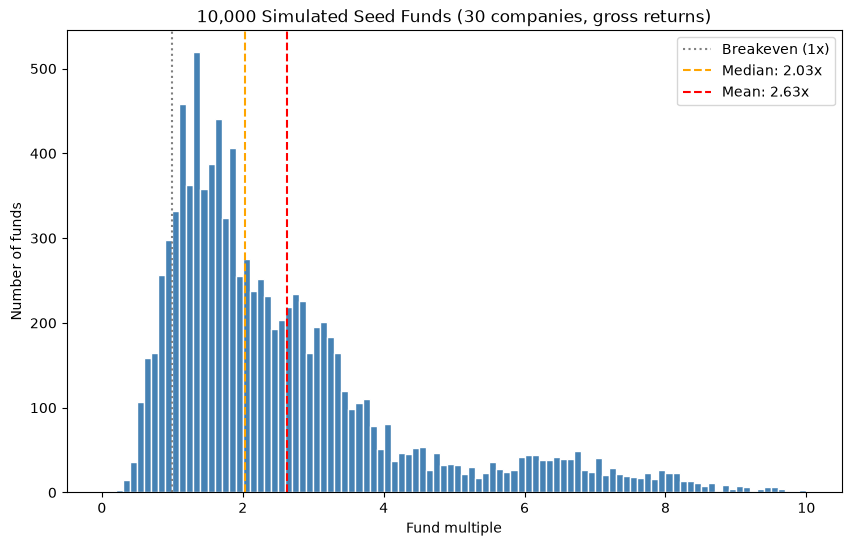

In [41]:
import matplotlib.pyplot as plt

results_30 = np.array([simulate_fund(30) for _ in range(10000)])
median_30 = np.median(results_30)
mean_30 = results_30.mean()

plt.figure(figsize = (10,6))
plt.hist(results_30, bins = 100, range = (0,10), color = "steelblue", edgecolor = "white")
plt.axvline(1, color="gray", linestyle=":", label="Breakeven (1x)")
plt.axvline(median_30, color="orange", linestyle="--", label=f"Median: {median_30:.2f}x")
plt.axvline(mean_30, color="red", linestyle="--", label=f"Mean: {mean_30:.2f}x")
plt.title("10,000 Simulated Seed Funds (30 companies, gross returns)")
plt.xlabel("Fund multiple")
plt.ylabel("Number of funds")
plt.legend()
plt.savefig("fund_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### Results

Most funds land between about 1x and 3x, with a long tail stretching right toward rare funds returning 5x to 10x. The tallest bars sit below the median, so the most common result is lower than the typical fund, and this right skew pulls the average (red line) above the median (orange line). About 10% of funds fall left of the 1x breakeven line, losing money, even though every fund followed the same strategy.

### Chart 2: Portfolio Size Tradeoff

This chart plots the results from Section 4 side by side to show how the number of companies in a fund affects the chance of losing money and the median return.

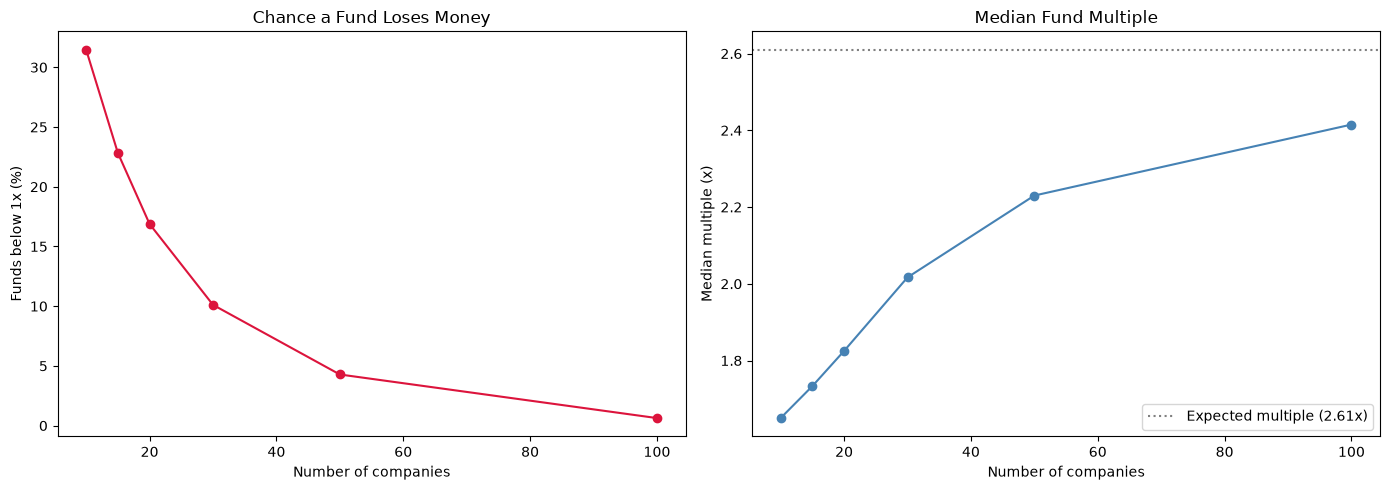

In [42]:
sizes = [10, 15, 20, 30 , 50, 100]
medians, losses = [], []

for size in sizes:
    r = np.array([simulate_fund(size) for _ in range(10000)])
    medians.append(np.median(r))
    losses.append((r<1).mean()*100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(sizes, losses, marker="o", color="crimson")
ax1.set_title("Chance a Fund Loses Money")
ax1.set_xlabel("Number of companies")
ax1.set_ylabel("Funds below 1x (%)")

ax2.plot(sizes, medians, marker="o", color="steelblue")
ax2.axhline(2.61, color="gray", linestyle=":", label="Expected multiple (2.61x)")
ax2.set_title("Median Fund Multiple")
ax2.set_xlabel("Number of companies")
ax2.set_ylabel("Median multiple (x)")
ax2.legend()

plt.tight_layout()
plt.savefig("portfolio_size.png", dpi=150, bbox_inches="tight")
plt.show()

### Results

The left chart shows that the chance of losing money drops quickly as companies are added, from about 30% at 10 companies to under 5% at 50, then levels off near zero. The right chart shows the median return rising as the fund grows, but more slowly over time, as it approaches the 2.61x expected multiple (dotted line). Each added company helps, but less than the one before.

In this code, there is no seed, so every time it is run, the results will vary slightly, but the shape of both charts stays the same.